### **E-OBS daily gridded meteorological data for Europe from 1950 to present derived from in-situ observations**

In [1]:
import xarray as xr

In [2]:
eobs = xr.open_dataset(r'C:\Users\Pandit\Downloads\e411e934934c6856e270ceaba69c0c1e\hu_ens_mean_0.1deg_reg_v31.0e.nc')

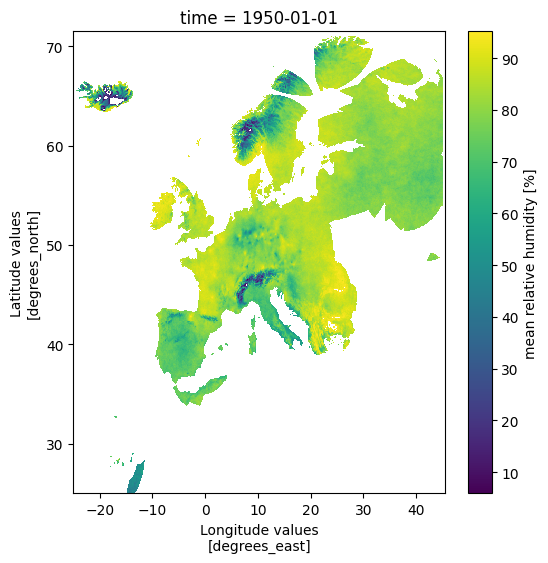

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (6,6))
eobs.hu.isel(time = 0).plot(ax = ax)

<Axes: >

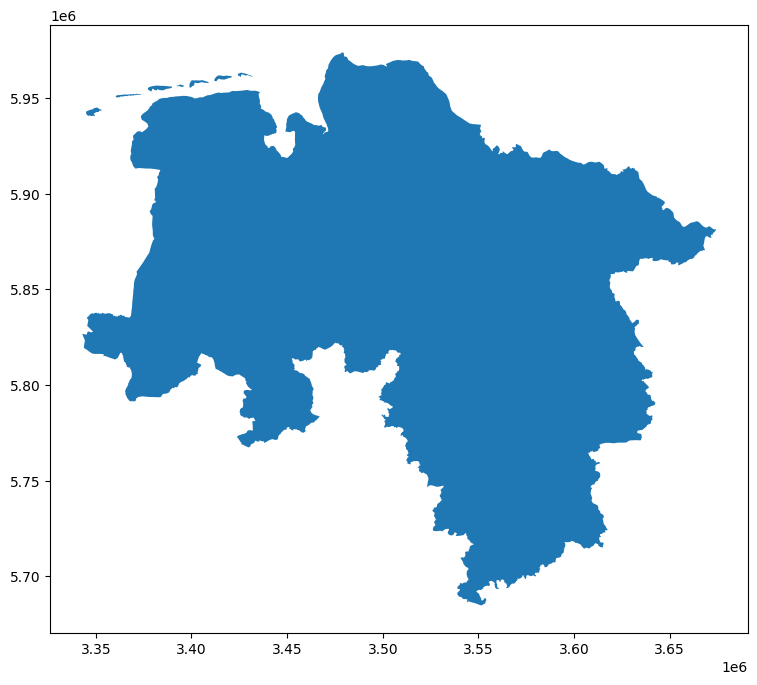

In [4]:
import geopandas as gpd
lx = gpd.read_file(r'C:\Users\Pandit\Downloads\Lager_Hase_R\Lager_Hase\data\spatial data\administration\niedersachsen_grenze.shp')
fig, ax = plt.subplots(figsize = (9,9))
lx.plot(ax = ax)

<Axes: >

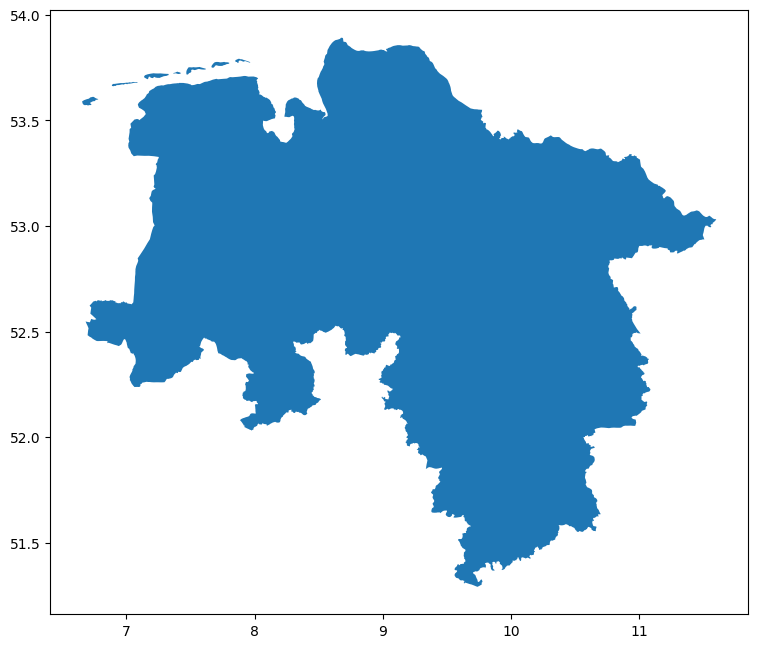

In [5]:
lx_4326 = lx.to_crs('EPSG:4326')
fig, ax = plt.subplots(figsize = (9,9))
lx_4326.plot(ax = ax)

In [6]:
lx_bounds = lx_4326.total_bounds
lx_bounds

array([ 6.65691261, 51.2919306 , 11.5984934 , 53.89157228])

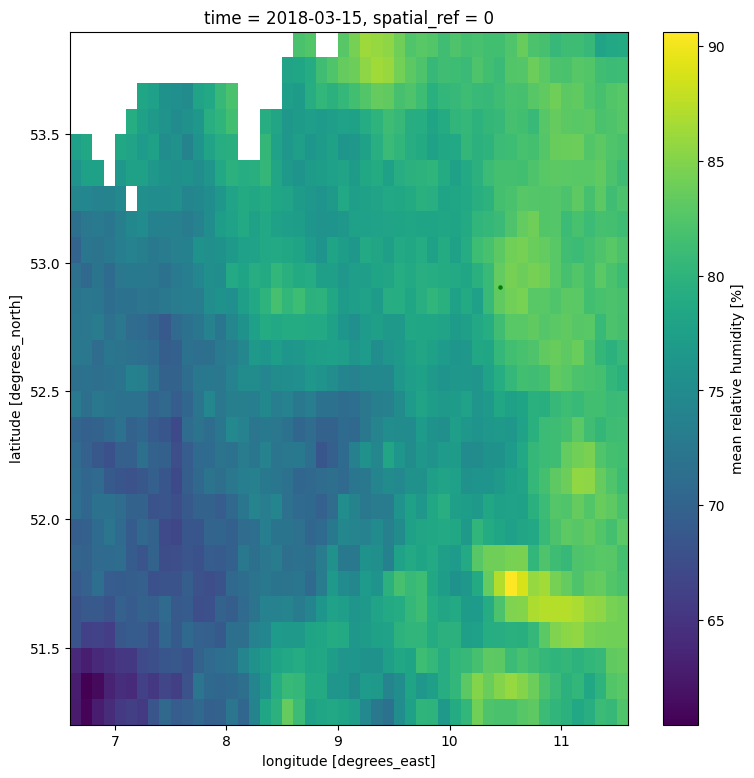

In [7]:
import rioxarray
from shapely.geometry import mapping
eobs = eobs.rio.write_crs('EPSG:4326')
eobs_lx = eobs.rio.clip_box(*lx_bounds)

fig, ax = plt.subplots(figsize = (9,9))
eobs_lx.hu.sel(time = '2018-03-15').plot(ax = ax)
ax.scatter(x=10.451666, y=52.90611, color = 'green', s = 5)

### Processing all data (required 7 variables)

In [8]:
def hamerstorff_data(file_path):
    # eobs data 
    eobs = xr.open_dataset(file_path)
    eobs = eobs.sel(time = slice('1990-01-01', None))
    eobs = eobs.rio.write_crs('EPSG:4326')
    
    # niedersacher shape file
    lx = gpd.read_file(r'C:\Users\Pandit\Downloads\Lager_Hase_R\Lager_Hase\data\spatial data\administration\niedersachsen_grenze.shp')
    lx_4326 = lx.to_crs('EPSG:4326')
    lx_bounds = lx_4326.total_bounds
    
    # eobs data for niedersachen
    eobs_lx = eobs.rio.clip_box(*lx_bounds)

    # filling missing values                          # previous extraction showed that only hu has missing values so only filling the gaps for hu
    if 'hu' in eobs_lx.data_vars:
        eobs_lx_filled = eobs_lx.rio.interpolate_na()

    else:
        eobs_lx_filled = eobs_lx
    
    hamerstorff = eobs_lx_filled.interp( longitude=10.451666, latitude=52.90611, method='linear')
    df_hamerstorff = hamerstorff.to_dataframe()

    return df_hamerstorff

#### all 7 variables extraction for hamerstorf

In [9]:
import os
import glob

In [11]:
input_folder = r'C:\Users\Pandit\Downloads\e411e934934c6856e270ceaba69c0c1e'
output_folder = r'C:\Users\Pandit\Downloads\hamerstorf_excel'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [12]:
files = glob.glob(os.path.join(input_folder, "*.nc"))

for file_path in files:
    file_name = os.path.basename(file_path)
    excel_name = file_name.replace(".nc", ".xlsx")
    print(f"Processing: {file_name}  ")
    
   
    df = hamerstorff_data(file_path)

    output_path = os.path.join(output_folder, excel_name)
    df.to_excel(output_path)
    
    print(f"Saved to: {output_path}")

print("Done!")

Processing: fg_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\fg_ens_mean_0.1deg_reg_v31.0e.xlsx
Processing: hu_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\hu_ens_mean_0.1deg_reg_v31.0e.xlsx
Processing: qq_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\qq_ens_mean_0.1deg_reg_v31.0e.xlsx
Processing: rr_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\rr_ens_mean_0.1deg_reg_v31.0e.xlsx
Processing: tg_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\tg_ens_mean_0.1deg_reg_v31.0e.xlsx
Processing: tn_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\tn_ens_mean_0.1deg_reg_v31.0e.xlsx
Processing: tx_ens_mean_0.1deg_reg_v31.0e.nc  
Saved to: C:\Users\Pandit\Downloads\hamerstorf_excel\tx_ens_mean_0.1deg_reg_v31.0e.xlsx
Done!


### hamerstorf data

In [13]:
import pandas as pd
file_dir = r'C:\Users\Pandit\Downloads\hamerstorf_excel'
df_hamerstorf = None
for files in os.listdir(file_dir):
    file_path = os.path.join(file_dir, files)
        # # print(file_path)
    if file_path.endswith('.xlsx'): 
        data = pd.read_excel(file_path)
        data = data[data['time'] >= '1980-01-01']
    
        if 'latitude' in data.columns:
            data['latitude'] = data['latitude'].round(2)
        if 'longitude' in data.columns:
            data['longitude'] = data['longitude'].round(2)
        
        # merge all data
        if df_hamerstorf is None:
            df_hamerstorf = data
    
        else:
            df_hamerstorf = pd.merge(df_hamerstorf, data, on = ['time','latitude', 'longitude', 'spatial_ref'] , how = 'inner')


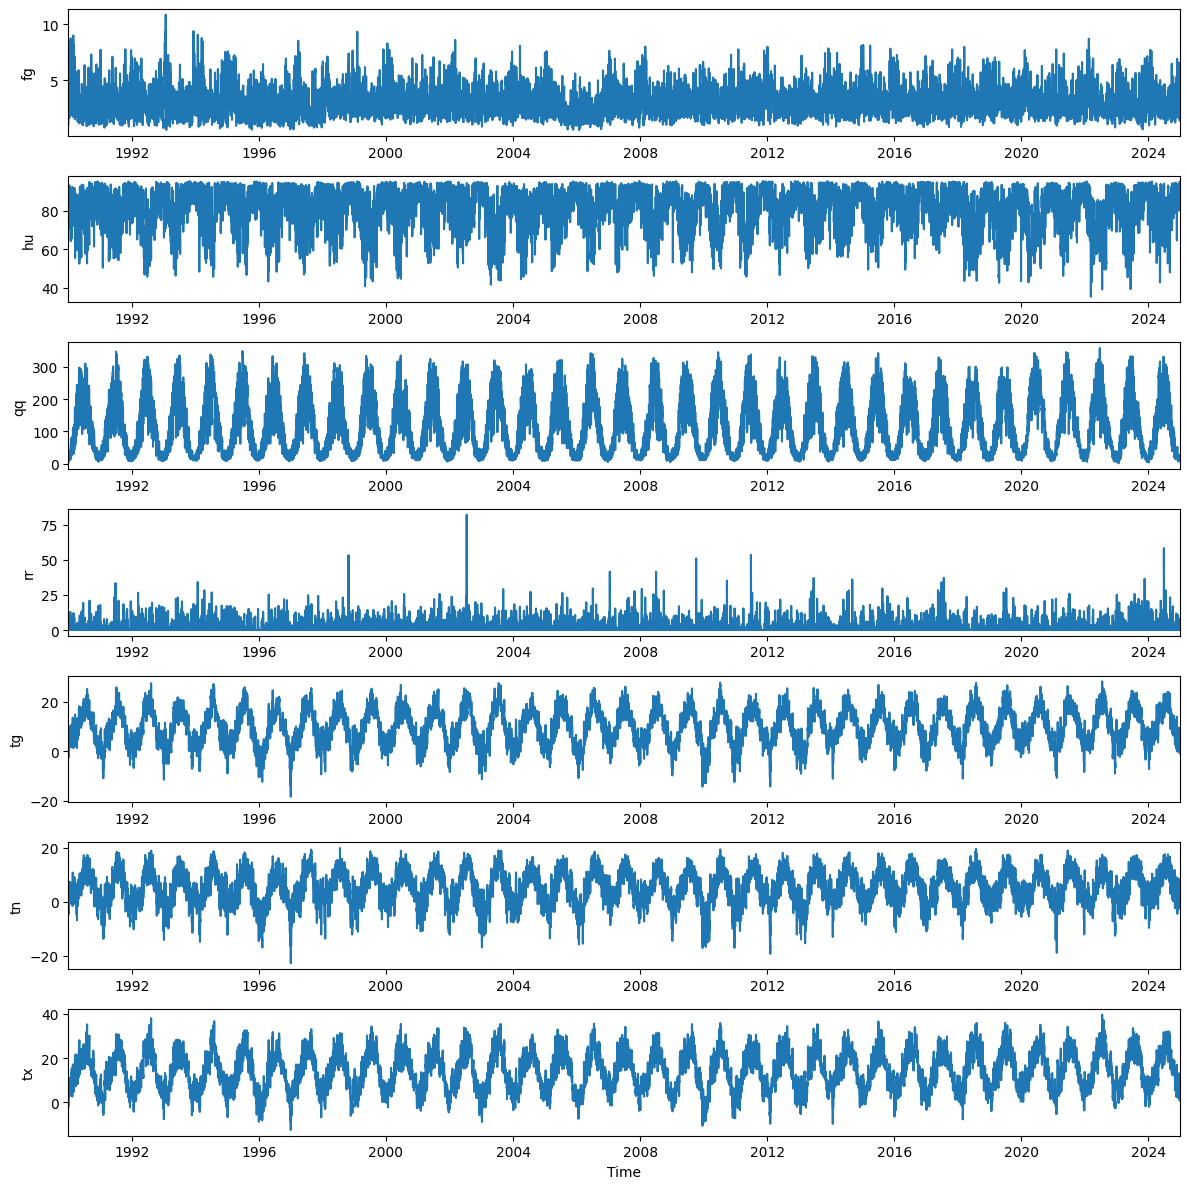

In [14]:
fig, ax = plt.subplots(7, 1, figsize = (12,12))
cols = ['fg'] + list(df_hamerstorf.columns[5:])

for i, cols_name in enumerate(cols):
    #print(f'{i}:{cols_name}')
    ax[i].plot(df_hamerstorf['time'], df_hamerstorf[cols_name])
    ax[i].set_ylabel(cols_name, fontsize=10)
    ax[i].set_xlim(pd.to_datetime('1990-01-01'), pd.to_datetime('2024-12-31'))
    
plt.xlabel("Time")
plt.tight_layout() 
plt.show()

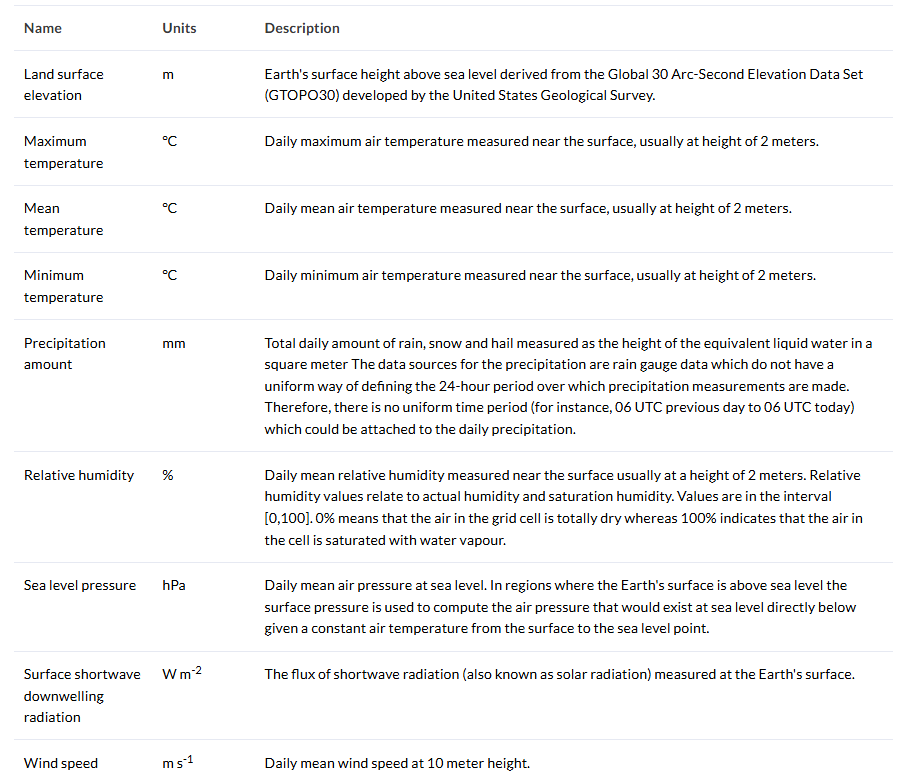

In [15]:
from IPython.display import Image, display
display(Image('image.png'))

**1. convert the 10m wind speed to 2m wind speed as the Penman-Monteith equation requires wind speed at 2m from the surface**
**2. convert the Wm-2 radiation into (MJm-2)**
    


In [16]:
import pyet

In [17]:
def et_calcn(data):
    data = data.drop(columns = ['spatial_ref', 'longitude', 'latitude'])
    data['time'] = pd.to_datetime(data['time'])
    data = data.set_index('time')
    data['rs'] = data['qq'] * 0.0864
    data['u2'] = data['fg'] * 0.748
    lat_rad = 0.92345

    data['eto'] = pyet.pm_fao56(
        tmean = data['tg'], 
        wind = data['u2'], 
        rs = data['rs'], 
        tmax = data['tx'], 
        tmin = data['tn'], 
        rh = data['hu'], 
        lat = lat_rad, 
        elevation= 65, 
    )

    return data

In [18]:
data = et_calcn(df_hamerstorf)
data.head()

,fg,hu,qq,rr,tg,tn,tx,rs,u2,eto
time,,,,,,,,,,
1990-01-01,1.027759,83.031985,4.000000,0.000000,-2.568970,-3.079558,-2.026225,0.345600,0.768764,0.108712
1990-01-02,1.357336,84.382840,10.000000,0.000000,-1.469661,-2.775930,-1.389041,0.864000,1.015287,0.180155
1990-01-03,2.459910,76.226190,11.000000,0.000000,-1.235469,-1.927494,-0.355922,0.950400,1.840012,0.404850
1990-01-04,2.668960,79.196049,21.455562,1.154445,-2.068321,-4.520269,-1.013871,1.853761,1.996382,0.327854
1990-01-05,2.147759,92.987719,11.007900,1.365249,0.995155,-1.113035,1.505509,0.951083,1.606524,0.150894


In [19]:
def D_calculation(data):
    weather = data [['rr', 'eto']]
    weather.columns = ['pcp', 'eto']
    df = weather.copy()
    df_monthly = df.resample('ME').agg({'pcp':'sum', 'eto':'sum'})
    df_monthly['D'] = df_monthly['pcp'] - df_monthly['eto']
    df_monthly['D6'] = df_monthly['D'].rolling(window = 6).sum()
    return df_monthly

In [20]:
df_monthly = D_calculation(data)
df_monthly.tail()

,pcp,eto,D,D6
time,,,,
2024-08-31,33.601112,102.688311,-69.087199,-97.627824
2024-09-30,69.061622,65.167684,3.893938,-89.300000
2024-10-31,47.188114,22.914659,24.273454,-68.609952
2024-11-30,56.456476,12.945501,43.510975,-6.804682
2024-12-31,49.368679,9.949521,39.419158,14.599922


In [21]:
from scipy.stats import genextreme as gev
from scipy.stats import fisk

In [30]:
def dist_fit_plot_mle(sample, distn_type, plt_title, save_fig):  # distn_type = 'fisk' and gev

    # estimate parameters 
    c, loc, sc = distn_type.fit(sample)
    
    fig, ax = plt.subplots(1,3, figsize = (14,6))
    # 1.  Distribution Fit Plot
    ax[0].hist(sample, bins = 'auto', density = True)
    
    x = np.linspace(min(sample), max(sample), 100)
    # plot pdf
    ax[0].plot(x, distn_type.pdf(x, c, loc, sc), 'r-', lw = 2, alpha = 0.6, label = 'Fitted Log-Logistic')
    ax[0].set_xlabel('6-Month Climatic Water Balance')
    ax[0].set_ylabel('PDF')
    ax[0].set_title('PDF Fit')
    ax[0].legend()
    
    # 2. Q-Q plot
    st.probplot(sample, dist = distn_type(c, loc, sc), plot= ax[1])
    ax[1].set_title('Q-Q Plot')
    
    # 3. P-P plot
    sorted_values = np.sort(sample)
    ecdf = np.arange(1, len(sample)+1) / (len(sample)+1)
    tcdf = distn_type.cdf(sorted_values, c, loc, sc)
    ax[2].plot(ecdf, tcdf, 'o')
    ax[2].plot([0,1], [0,1], 'r--')
    ax[2].set_xlabel("Empirical CDF")
    ax[2].set_ylabel("Theoretical CDF")
    ax[2].set_title("P–P Plot")
    
    
    fig.suptitle(plt_title)
    plt.tight_layout()
    plt.savefig(save_fig, dpi = 300)
    plt.show()

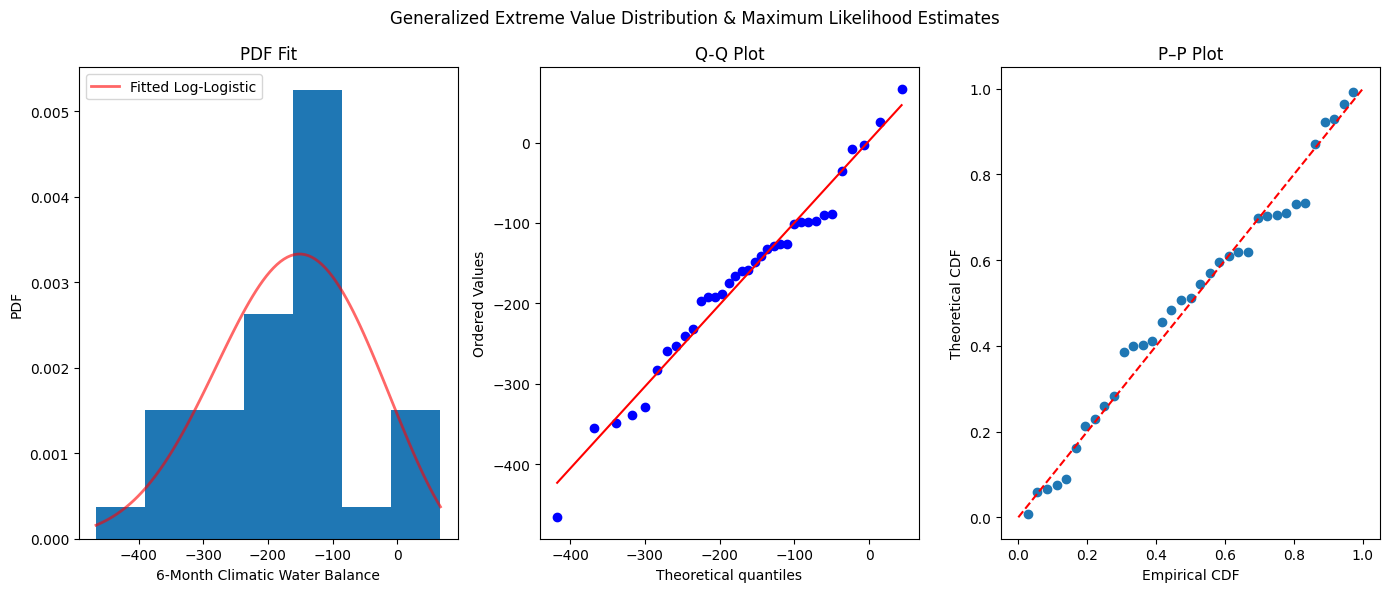

In [31]:
import numpy as np
import scipy.stats as st 
sample = df_monthly[df_monthly.index.month == 9 ]['D6'].dropna()
save_fig1 = r'C:\Users\Pandit\Desktop\documentation\spei_eobs\gev_mle_fit.png'
dist_fit_plot_mle(sample, gev, 'Generalized Extreme Value Distribution & Maximum Likelihood Estimates', save_fig1)

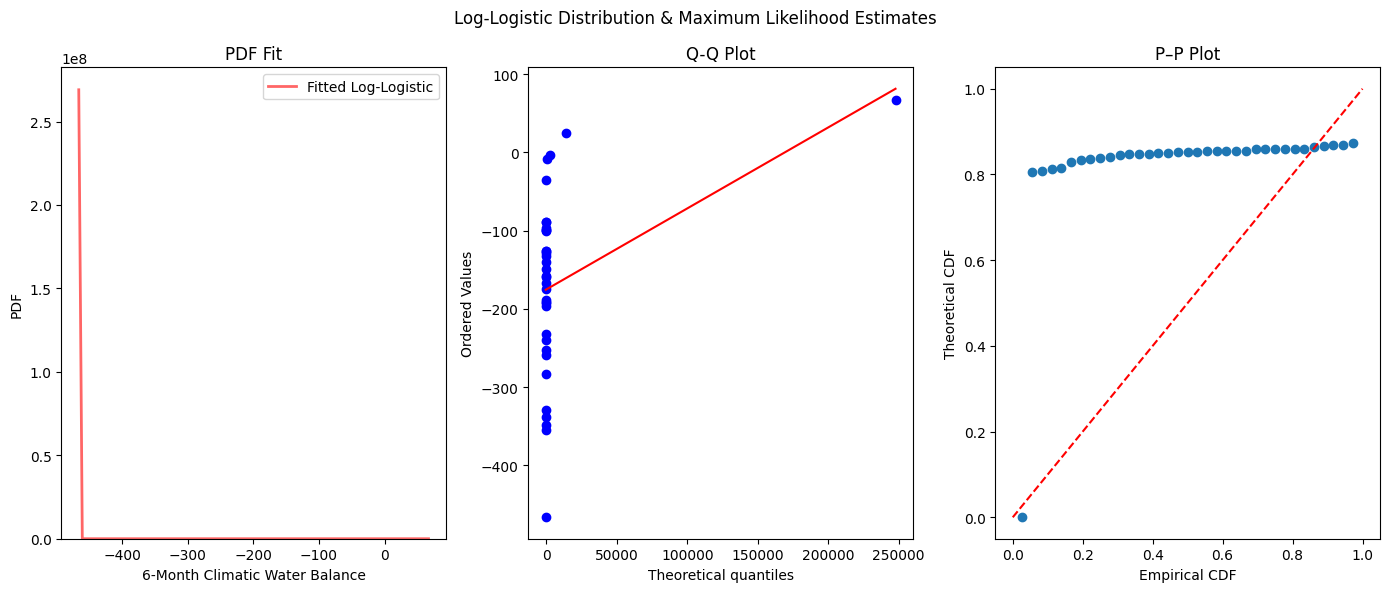

In [51]:
save_fig2 = r'C:\Users\Pandit\Desktop\documentation\spei_eobs\loglogistic_mle_fit.png'
dist_fit_plot_mle(sample, fisk, 'Log-Logistic Distribution & Maximum Likelihood Estimates', save_fig2)

In [33]:
from scipy.stats import norm

In [34]:
def spei_estimation(sample):
    # gev distribution
    c, loc, sc = gev.fit(sample)
    cdf = gev.cdf(sample, c, loc, sc)
    # spei sept
    spei_gev = norm.ppf(cdf)
    #print(spei_gev)

    # log logistic
    shape, location, scale = fisk.fit(sample)
    cdf_fisk = fisk.cdf(sample, shape, location, scale)
    spei_fisk = norm.ppf(cdf_fisk)
    #print(spei_fisk)

    #dataframe
    date = pd.date_range('1990-09-01', '2024-09-01', freq = '12MS')
    df_spei_mle = pd.DataFrame({'year': date , 'spei_log_logistic': spei_fisk, 'spei_gev': spei_gev})
    return df_spei_mle

In [39]:
def eobs_data_spei_plot(spei_data, title1, title2, savefig):
    """
    Generates plot for the Spei Data 
    """
    # plotting the result
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))
    
    # glo plot
    ax[0].plot(spei_data['year'], spei_data['spei_log_logistic'], color='blue', label = 'Spei')
    
    ax[0].axhline(1, linestyle='--', color='red', label='Wet Threshold')
    ax[0].axhline(-1, linestyle='--', color='green', label='Dry Threshold')
    
    ax[0].set_title(title1)
    ax[0].set_ylabel('SPEI')
    ax[0].set_xlabel('Year')
    ax[0].set_xlim(pd.to_datetime('2006-09-01'), pd.to_datetime('2022-09-01'))
    ax[0].legend()
    
    # gev plot
    ax[1].plot(spei_data['year'], spei_data['spei_gev'], color='blue')
    
    ax[1].axhline(1, linestyle='--', color='red', label='Wet Threshold')
    ax[1].axhline(-1, linestyle='--', color='green', label='Dry Threshold')
    
    ax[1].set_title(title2)
    ax[1].set_ylabel('SPEI')
    ax[1].set_xlabel('Year')
    ax[1].set_xlim(pd.to_datetime('2006-01-01'), pd.to_datetime('2022-12-31'))
    ax[1].legend()
    
    plt.tight_layout()
    plt.savefig(savefig, dpi = 300)
    plt.show()

In [36]:
df_spei_mle = spei_estimation(sample)

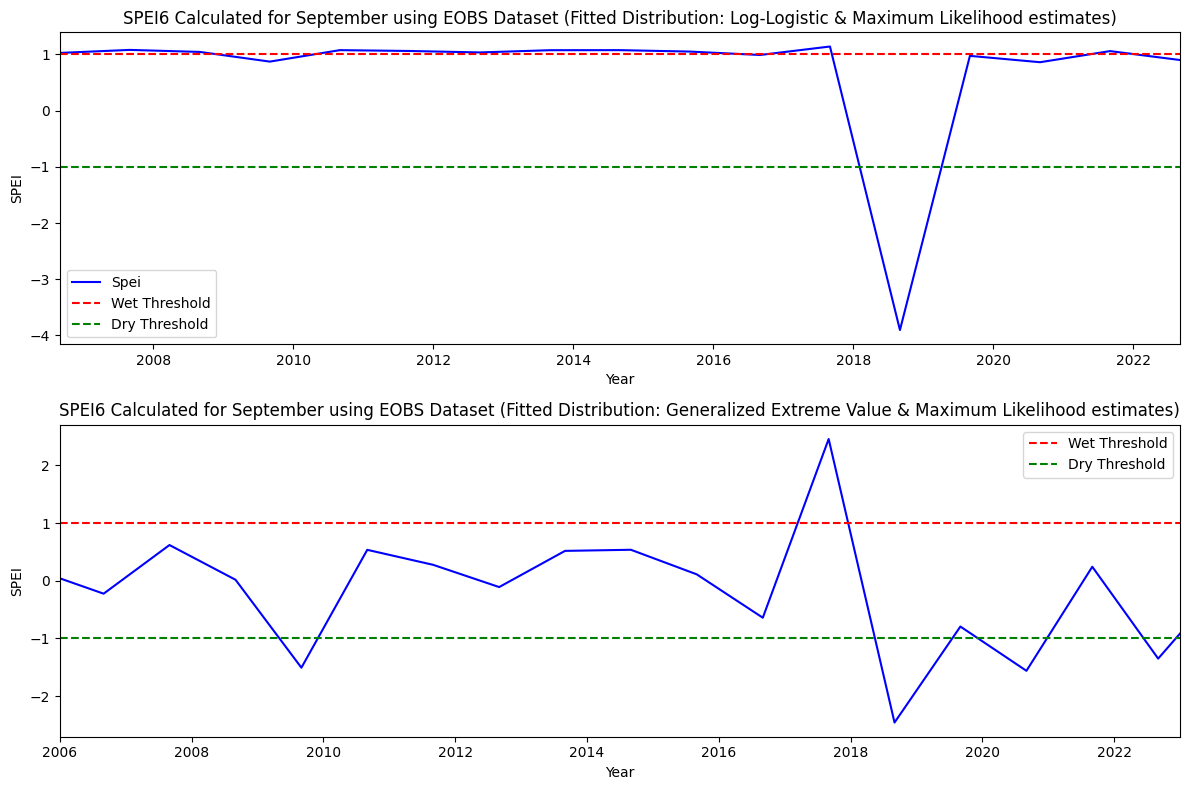

In [40]:
savefig3 = r'C:\Users\Pandit\Desktop\documentation\spei_eobs\spei_mle_fit.png'
eobs_data_spei_plot(df_spei_mle, 'SPEI6 Calculated for September using EOBS Dataset (Fitted Distribution: Log-Logistic & Maximum Likelihood estimates)', 
                    'SPEI6 Calculated for September using EOBS Dataset (Fitted Distribution: Generalized Extreme Value & Maximum Likelihood estimates)', savefig3)

#### Estimating the parameters using the unbiased PWMs, as suggested in the paper  https://doi.org/10.1002/joc.3887

In [42]:
# ! pip install lmoments3

In [41]:
import lmoments3
from lmoments3 import distr

In [43]:
def dist_fit_plot_unbiased_pwm(sample, distn_type, plt_title, savefig):
    #  distribution
    if distn_type == 'glo':
        dist = distr.glo
    elif distn_type == 'gev':
        dist = distr.gev
    else:
        raise ValueError("distn_type must be 'glo' or 'gev'")

    # parameter estimation
    params = dist.lmom_fit(sample)

    # plots
    fig, ax = plt.subplots(1, 3, figsize=(14, 6))

    # 1. Histogram + PDF
    ax[0].hist(sample, bins='auto', density=True, alpha=0.6)
    x = np.linspace(min(sample), max(sample), 200)
    ax[0].plot(x, dist.pdf(x, **params), 'r-', lw=2, label='Fitted PDF')
    ax[0].set_xlabel('6-Month Climatic Water Balance')
    ax[0].set_ylabel('PDF')
    ax[0].set_title('PDF Fit')
    ax[0].legend()

    # 2. Q-Q plot
    st.probplot(sample, dist=dist, sparams=list(params.values()), plot=ax[1])
    ax[1].set_title('Q-Q Plot')

    # 3. P-P plot
    sorted_values = np.sort(sample)
    emp_cdf = np.arange(1, len(sample) + 1) / (len(sample) + 1)
    theo_cdf = dist.cdf(sorted_values, **params)

    ax[2].plot(emp_cdf, theo_cdf, 'o')
    ax[2].plot([0, 1], [0, 1], 'r--')
    ax[2].set_xlabel("Empirical CDF")
    ax[2].set_ylabel("Theoretical CDF")
    ax[2].set_title("P–P Plot")

    fig.suptitle(plt_title)

    plt.tight_layout()
    plt.savefig(savefig, dpi = 300)
    plt.show()


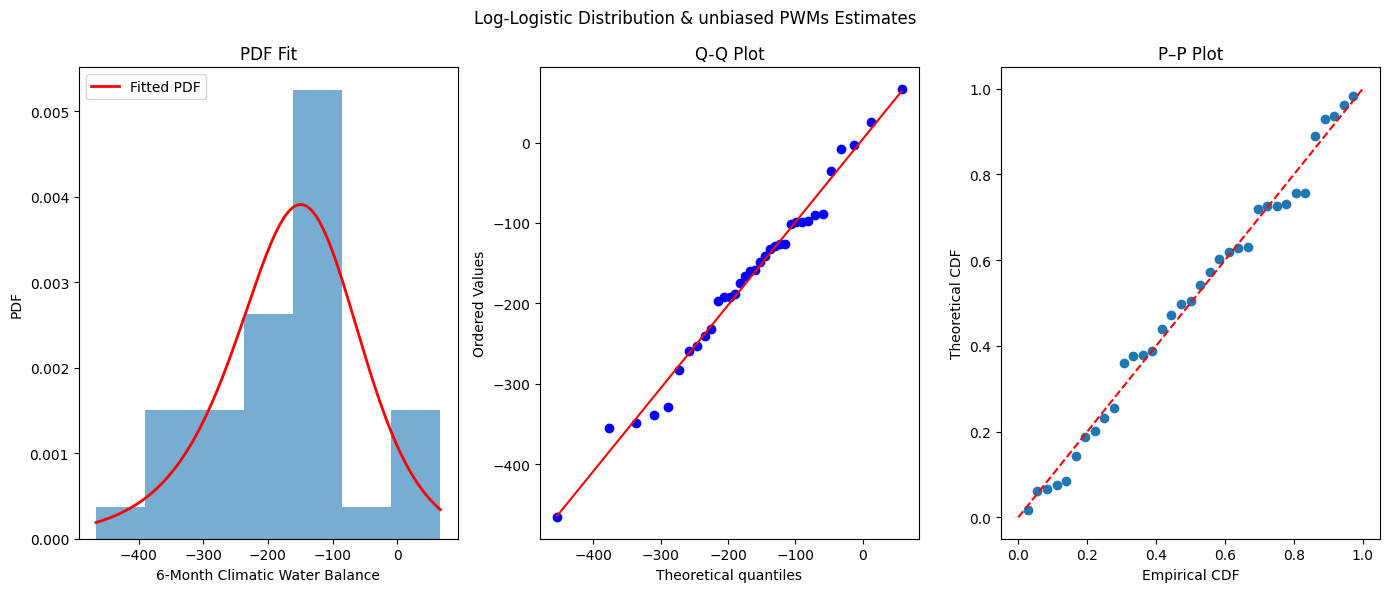

In [45]:
savefig4 = r'C:\Users\Pandit\Desktop\documentation\spei_eobs\loglogistic_unbiasedpwm_fit.png'
dist_fit_plot_unbiased_pwm(sample, 'glo', 'Log-Logistic Distribution & unbiased PWMs Estimates', savefig4)

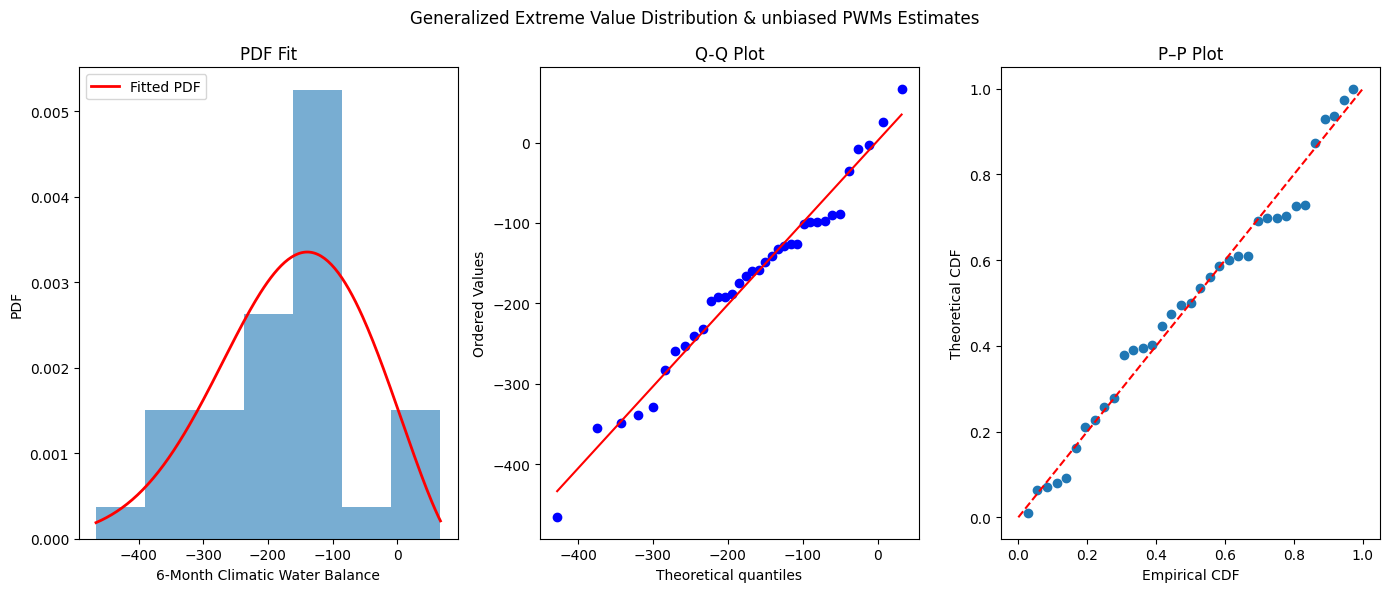

In [46]:
savefig5 = r'C:\Users\Pandit\Desktop\documentation\spei_eobs\gev_unbiasedpwm_fit.png'
dist_fit_plot_unbiased_pwm(sample, 'gev', 'Generalized Extreme Value Distribution & unbiased PWMs Estimates', savefig5)

In [47]:
def spei_lmoments(sample):
    # parameter estimation for both distr    
    params_glo = distr.glo.lmom_fit(sample)
    params_gev = distr.gev.lmom_fit(sample)

    # cdfs 
    cdf_glo = distr.glo.cdf(sample, **params_glo)
    cdf_gev = distr.gev.cdf(sample, **params_gev)

    # spei estimation
    spei_glo = norm.ppf(cdf_glo)
    spei_gev = norm.ppf(cdf_gev)

    # data frame
    date = pd.date_range('1990-09-01', '2024-09-01', freq = '12MS')
    df_spei = pd.DataFrame(
        {
            'year': date, 
             'spei_log_logistic': spei_glo, 
             'spei_gev': spei_gev
        }
    )
    
    return df_spei

In [48]:
df_spei_lmoment = spei_lmoments(sample)
df_spei_lmoment.head()

,year,spei_log_logistic,spei_gev
0,1990-09-01,0.328696,0.276169
1,1991-09-01,-0.314873,-0.276057
2,1992-09-01,-0.836656,-0.750901
3,1993-09-01,1.223323,1.146590
4,1994-09-01,0.333046,0.279949


In [49]:
def eobs_data_spei_plot_unbiased_pwm(spei_data, title1, title2, savefig):
    """
    Generates plot for the Spei Data 
    """
    # plotting the result
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))
    
    # glo plot
    ax[0].plot(spei_data['year'], spei_data['spei_log_logistic'], color='blue', label = 'Spei')
    
    ax[0].axhline(1, linestyle='--', color='red', label='Wet Threshold')
    ax[0].axhline(-1, linestyle='--', color='green', label='Dry Threshold')
    
    ax[0].set_title(title1)
    ax[0].set_ylabel('SPEI')
    ax[0].set_xlabel('Year')
    ax[0].set_xlim(pd.to_datetime('2006-09-01'), pd.to_datetime('2022-09-01'))
    ax[0].legend()
    
    # gev plot
    ax[1].plot(spei_data['year'], spei_data['spei_gev'], color='blue')
    
    ax[1].axhline(1, linestyle='--', color='red', label='Wet Threshold')
    ax[1].axhline(-1, linestyle='--', color='green', label='Dry Threshold')
    
    ax[1].set_title(title2)
    ax[1].set_ylabel('SPEI')
    ax[1].set_xlabel('Year')
    ax[1].set_xlim(pd.to_datetime('2006-09-01'), pd.to_datetime('2022-09-31'))
    ax[1].legend()
    
    plt.tight_layout()
    plt.savefig(savefig, dpi = 300)
    plt.show()

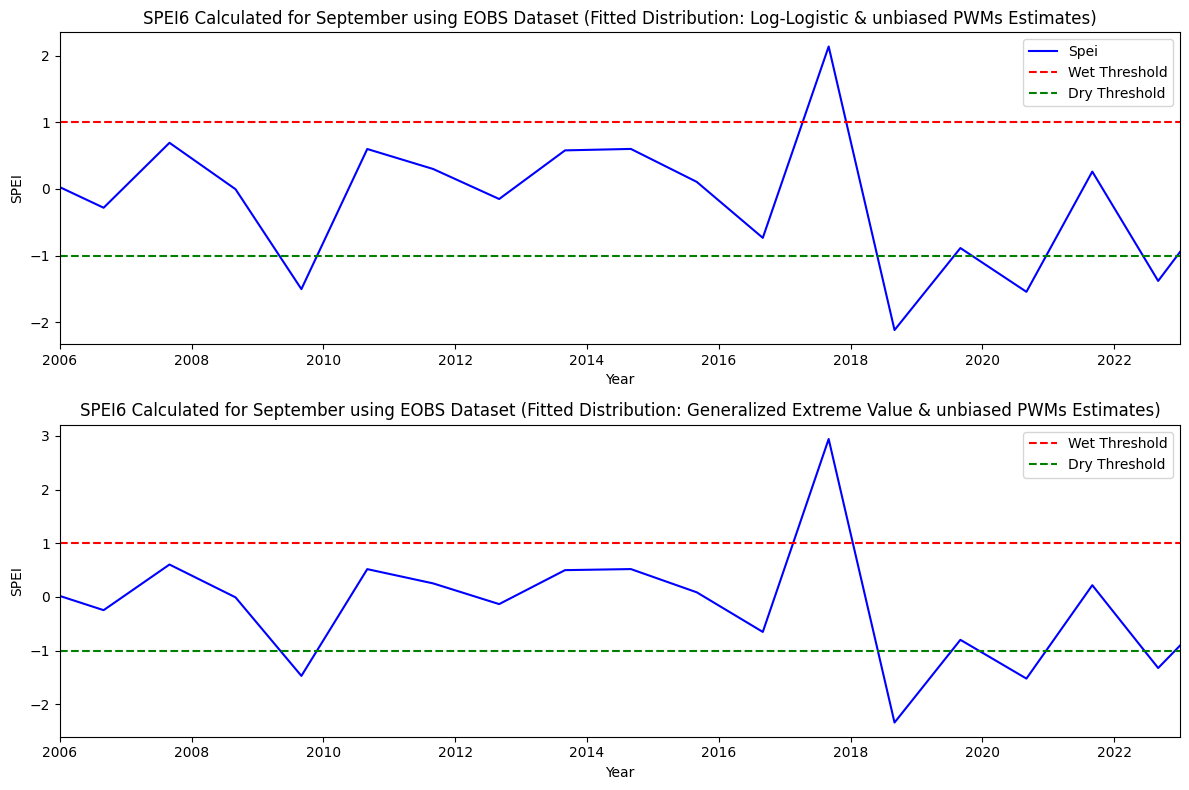

In [50]:
savefig6 = r'C:\Users\Pandit\Desktop\documentation\spei_eobs\spei_ubiased_pwm_fit.png'
eobs_data_spei_plot_unbiased_pwm(df_spei_lmoment, 'SPEI6 Calculated for September using EOBS Dataset (Fitted Distribution: Log-Logistic & unbiased PWMs Estimates)', 
                    'SPEI6 Calculated for September using EOBS Dataset (Fitted Distribution: Generalized Extreme Value & unbiased PWMs Estimates)', savefig6)